# All the President's Moods

In the past decade, a certain public figure has been very active on Twitter/X...

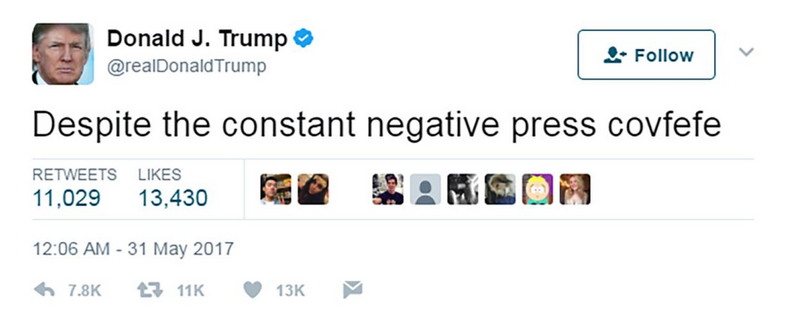

## Trump and Twitter/X

During his tenure as US President, Donald Trump maintained a steady presence on Twitter/X. Since the words of the politicians tend to affect the behavior of other people, including markets, there is a sizable literature quantifying the effect of politician speeches on market behavior in the aggregate. 


## Case Study: The 2020 Election

Unllke other politicians, Trump's tweets were both impassioned and plentiful. This means Twitter/X can give a large volume of reactions to work with that have a distribution of "sentiment."

In this example, we will look at Trump's tweets around the 2020 election. 

In [1]:
import pandas as pd
import json 
import matplotlib.pyplot as plt
import matplotlib
import re
import string
from nltk.corpus import stopwords
import regex
import nltk
from datetime import timedelta
from nltk.sentiment.vader import SentimentIntensityAnalyzer

## 1. Read Tweets

Reading Trump Tweets

In json format:

In [2]:
dir_ = "C:/Users/jhtchns2/Box/ACE_592_SAE/Class_Examples/1_Text/"
# Opening the tweet file as f, using json to load it
with open(dir_+"Trump_tweets.json") as f:
    tweets = json.load(f)

Let's extract some features and put them in a dataframe:

In [3]:
df = pd.DataFrame()

# Extract the full text of the tweet
df['full_text'] = [x['full_text'] for x in tweets]

# Get a list of users mentioned from each text
df['user_mentions'] = [[ x['screen_name'] for x in y['entities']['user_mentions'] ] for y in tweets]

# How many times was it retweeted
df['RTs'] = [x['retweet_count'] for x in tweets]

# How many times was it "liked"
df['favs'] = [x['favorite_count'] for x in tweets]

# If no RTs, Twitter censored it
df['censored'] = df['RTs']==0

### Note: extended text and retweets

In the case that there is an "extended_tweet" key, the "full_text" key does not exit.

If that is the case, you have to extract it doing something like this: 

An inelegant solution:

In [4]:
ext_text = []

for tweet in tweets:
    if "retweeted_status" in list(tweet.keys()): # Is one of the keys "retweeted_status"
        if "extended_tweet" in list(tweet['retweeted_status'].keys()): # Is one of they keys in "extended tweet"
            ext_text += [tweet['retweeted_status']['extended_tweet']['full_text']]
        else:
            ext_text += [tweet['retweeted_status']['full_text']] # If not, take "text"
    elif "extended_tweet" in list(tweet.keys()): # Is one of the keys "extended_tweet"
        ext_text += [tweet['extended_tweet']['full_text']]
    else:
        ext_text += [tweet['full_text']] # If not, take "text"

df['text'] = ext_text

Time features

In [5]:
df['time_stamp'] = [x['created_at'] for x in tweets]

# Adjust from GMT to CT (Central Time)
df['time_stamp'] = pd.to_datetime(df['time_stamp']) - timedelta(hours=6)

# Get the YYYY-MM-DD for each tweet
df['date'] = df.time_stamp.apply(lambda x:  str(x)[:10])
df['date'] = pd.to_datetime(df.date)

C:\Users\jhtchns2\AppData\Local\Temp\ipykernel_24788\1417733714.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_stamp'] = pd.to_datetime(df['time_stamp']) - timedelta(hours=6)


To drop duplicates, I'll take the one with the most favorites.

In [6]:
# Sort by time, full text, and the number of likes
df = df.sort_values(by=['time_stamp','full_text',"favs"])

# Grouping on time stamp and text, take the last one (the one with more likes)
df = df.groupby(['time_stamp','full_text']).last().reset_index()

## Word Counts

### Top 10 Words
#### Remove Links and User Tags

I'm going to use regular expressions here

In [7]:
import re

# Find things that start with "http"
find_links = re.compile(r'http\S+')

# Find things that start with @
find_users = re.compile(r'@\w+')

# Find things that start with #
find_hashtags = re.compile(r'#\w+')

# Substitute what you find with an empty string
df['text_nolink'] = [find_links.sub("",x) for x in df['full_text']]

# Same, but with @
df['text_nolink'] = [find_users.sub("",x) for x in df['text_nolink']]

# Same but with #
df['text_nolink'] = [find_hashtags.sub("",x) for x in df['text_nolink']]

#### Remove punctuation and lowercase

In [8]:
import string
string.punctuation

# Same function, but add slightly different quotes
remv_punc = str.maketrans('','',string.punctuation + '“' +"‘"+'”')
# Lowercase and replace "\n" with " "
df['text_lower'] =  df['text_nolink'].str.lower().str.replace("\n"," ")
# Remove punctuation
df['text_clean'] = df.text_lower.str.translate(remv_punc)

#### Split into words

In [9]:
from nltk.corpus import stopwords
# Stopword list
sw_list = stopwords.words('english') + ['amp',''," "]
# Split the words into lists
df['words'] = [x.split(" ") for x in df['text_clean']]

#### Take out Stop Words

In [10]:
# Convert the text to a set, subtract the set of stopwords, turn into list
df['words'] = [[x for x in y if x not in sw_list] \
                        for y in df['words']]

#### Get the words counts

Slow way:

In [11]:
# value_counts for each tweet
series_list = [pd.Series(x).value_counts() for x in df['words']]

# Concat all the value counts, fillna(0), transpose, and reset_index()
word_df = pd.concat(series_list,axis=1).fillna(0).T.reset_index(drop=True)

In [12]:
# Get top 20 words
word_df.sum().sort_values(ascending=False).head(20)

biden           294.0
great           264.0
vote            232.0
joe             208.0
thank           186.0
people          133.0
get             120.0
big             108.0
trump           103.0
america         102.0
fake             89.0
president        88.0
pennsylvania     85.0
total            85.0
would            84.0
country          83.0
amendment        83.0
news             81.0
jobs             81.0
election         81.0
dtype: float64

If the data is big, that method is very memory and time-consuming.

I am going to use an sklean vectorizer here. Part of the reason sklearn is more efficient in this case is that it uses __sparse matrices__ to do the computations.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
# Create an instance, but use a stopword list
vct = CountVectorizer(stop_words=sw_list)
# Transform that word list into a sparse matrix
X = vct.fit_transform(list(df['text_clean']))

In [14]:
X

<1789x4003 sparse matrix of type '<class 'numpy.int64'>'
	with 18343 stored elements in Compressed Sparse Row format>

This matrix currently holds 18k entries, but somehow does it efficiently. How?

### Sparse Matrices
- Matrices where most of the elements are zero.
- If you are using int64, its taking up 64 bits just to put zeros. What a waste!
- One format is called __Compressed Sparse Row__ and holds this data more efficiently. From the Wikipedia page:
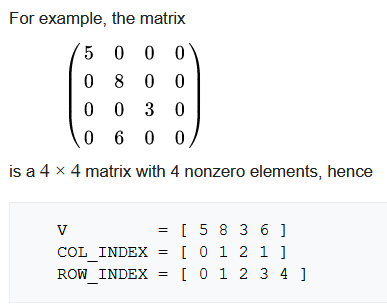    Holding three one-dimensional arrays is much more efficient than a giant two-dimensional array.

A handy feature here is that you can still do normal operations on a sparse matrix. I will sum it and then make it a dataframe:

In [15]:
# Convert X to dataframe after taking sum
word_counts = pd.DataFrame(X.sum(axis=0))

I can label columns by extracting the "feature names"

In [16]:
# Assign feature names as columns
word_counts.columns = vct.get_feature_names_out()
# Transpose to make the columns the rows
word_counts = word_counts.T

Top 10 words

In [17]:
word_counts[0].sort_values(ascending=False).head(10)

biden      319
great      264
vote       233
joe        215
thank      186
people     133
get        123
america    111
big        108
trump      106
Name: 0, dtype: int64

### Which of the words are hashtags and mentions?
How shall we find hashtags and mentions?

How you extract them is an exercise for you 

__(but here's a hint: CountVectorizer accepts regular expressions...)__

#### Bar Chart

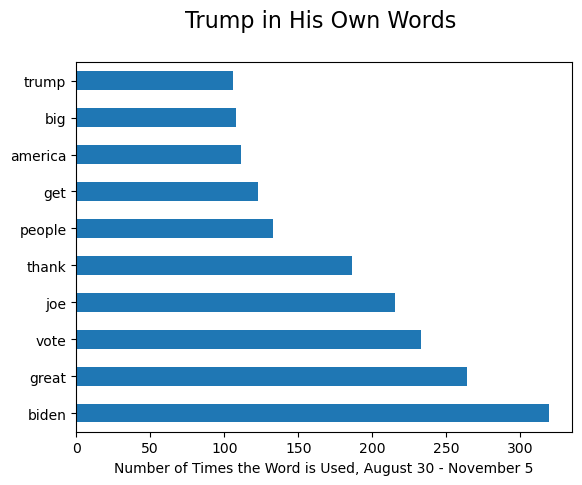

In [18]:
# Horizontal bar chart of top 10 word counts 
word_counts[0].sort_values(ascending=False).head(10).plot(kind='barh')
# Labels
plt.xlabel("Number of Times the Word is Used, August 30 - November 5")
plt.title("Trump in His Own Words \n",fontsize=16)
plt.savefig("trump_words.png",dpi=250,bbox_inches="tight")

### Most Favorited

In [19]:
# Sort by favorites, take first 5 rows
# Only use three columns (time, text, and favorites)
favor_5 = df.sort_values("favs",ascending=False).head()[['time_stamp','full_text','favs']]
# Rename those columns
favor_5.columns = ['Time Stamp',"Tweet",'Number of Favorites']

In [20]:
# This is an option I have to set to see the whole text 
pd.set_option('display.max_colwidth', None)
# Print those tweets
favor_5[['Tweet','Time Stamp',"Number of Favorites"]]

,Tweet,Time Stamp,Number of Favorites
773,"Tonight, @FLOTUS and I tested positive for COVID-19. We will begin our quarantine and recovery process immediately. We will get through this TOGETHER!",2020-10-01 22:54:06+00:00,1858018
775,"Going welI, I think! Thank you to all. LOVE!!!",2020-10-02 21:31:34+00:00,1202110
1770,WE ARE LOOKING REALLY GOOD ALL OVER THE COUNTRY. THANK YOU!,2020-11-03 17:15:55+00:00,957283
1771,I will be making a statement tonight. A big WIN!,2020-11-03 23:45:53+00:00,925883
1763,This Tweet from @realDonaldTrump has been withheld in response to a report from the copyright holder. Learn more.,2020-11-03 01:57:08+00:00,905506


## Tweet Volume

In [21]:
# Count the number of rows with that date 
top10_dates = df['date'].value_counts().head(10)
# Top 10
top10_dates

date
2020-11-02    69
2020-10-30    63
2020-10-12    63
2020-10-31    62
2020-10-27    61
2020-11-01    51
2020-09-08    48
2020-10-07    48
2020-10-13    46
2020-09-30    40
Name: count, dtype: int64

#### Some important dates:
- Sept 29th: First Presidential Debate
- Oct 15th: Planned Second Debate (which Trump refused to show up for).
- Oct 22nd: Final Debate
- Nov 3rd: Election Day

In [22]:
# Create a list of all the dates that occur 
# Sort the date column, drop duplicates
dates = df['date'].sort_values().drop_duplicates().reset_index(drop=True)

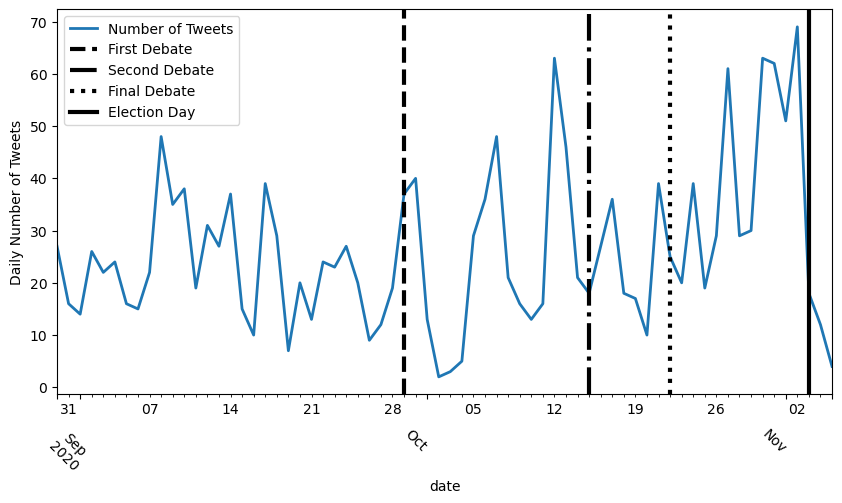

In [23]:
# Count the occurences of each date, plot on a figure
df.date.value_counts().sort_index().plot(label="Number of Tweets",figsize=(10,5),lw=2)

# Put lines where the important dates are
plt.axvline("2020-09-29",ls="--",color="black",label="First Debate",lw=3)
plt.axvline("2020-10-15",ls="-.",color="black",label="Second Debate",lw=3)
plt.axvline("2020-10-22",ls=":",color="black",label="Final Debate",lw=3)
plt.axvline("2020-11-03",ls="-",color="black",label="Election Day",lw=3)

# Label
plt.ylabel("Daily Number of Tweets")
plt.xticks(rotation=-45)
plt.legend(loc="upper left")

#### Top 5 words on those days

In [24]:
important_dates = ["2020-09-29","2020-10-15","2020-10-22","2020-11-03"]

In [25]:
# Concat the date of the tweet
word_df = pd.concat([df[['date']],word_df],axis=1)

def top5_words(date):
    this_day = word_df[word_df.date==date] # Words on that date
    word_sums = this_day.iloc[:,1:].sum() # Sum them
    top5_words = word_sums.sort_values(ascending=False).head().index # Get the list of top 5 word
    return list(top5_words) # Return the list
# For each date, find the top 5 words
words_on_days = pd.DataFrame([top5_words(x) for x in top10_dates.index]) 
# Number the columns 1-5
words_on_days.columns = [1,2,3,4,5] 
# Label the indices by the date
words_on_days.index = top10_dates.index

In [26]:
words_on_days

,1,2,3,4,5
date,,,,,
2020-11-02,vote,biden,joe,get,pennsylvania
2020-10-30,biden,vote,joe,would,get
2020-10-12,joe,biden,vote,big,sleepy
2020-10-31,total,complete,endorsement,amendment,vote
2020-10-27,thank,great,biden,vote,wisconsin
2020-11-01,biden,great,joe,vote,would
2020-09-08,great,biden,thank,money,new
2020-10-07,vote,biden,president,years,got
2020-10-13,pennsylvania,get,great,vote,people


## Sentiment Analysis

In [27]:
# Create the instance
sid = SentimentIntensityAnalyzer()
# Feed the tweet text into the analyzer, get compound score
pol_scores = [sid.polarity_scores(x)['compound'] for x in df['text_clean']]
# Make it a column of the dataframe
df['sentiment'] = pd.Series(pol_scores)
# Sort this by time
sent_ts = df.set_index("time_stamp").sort_index()

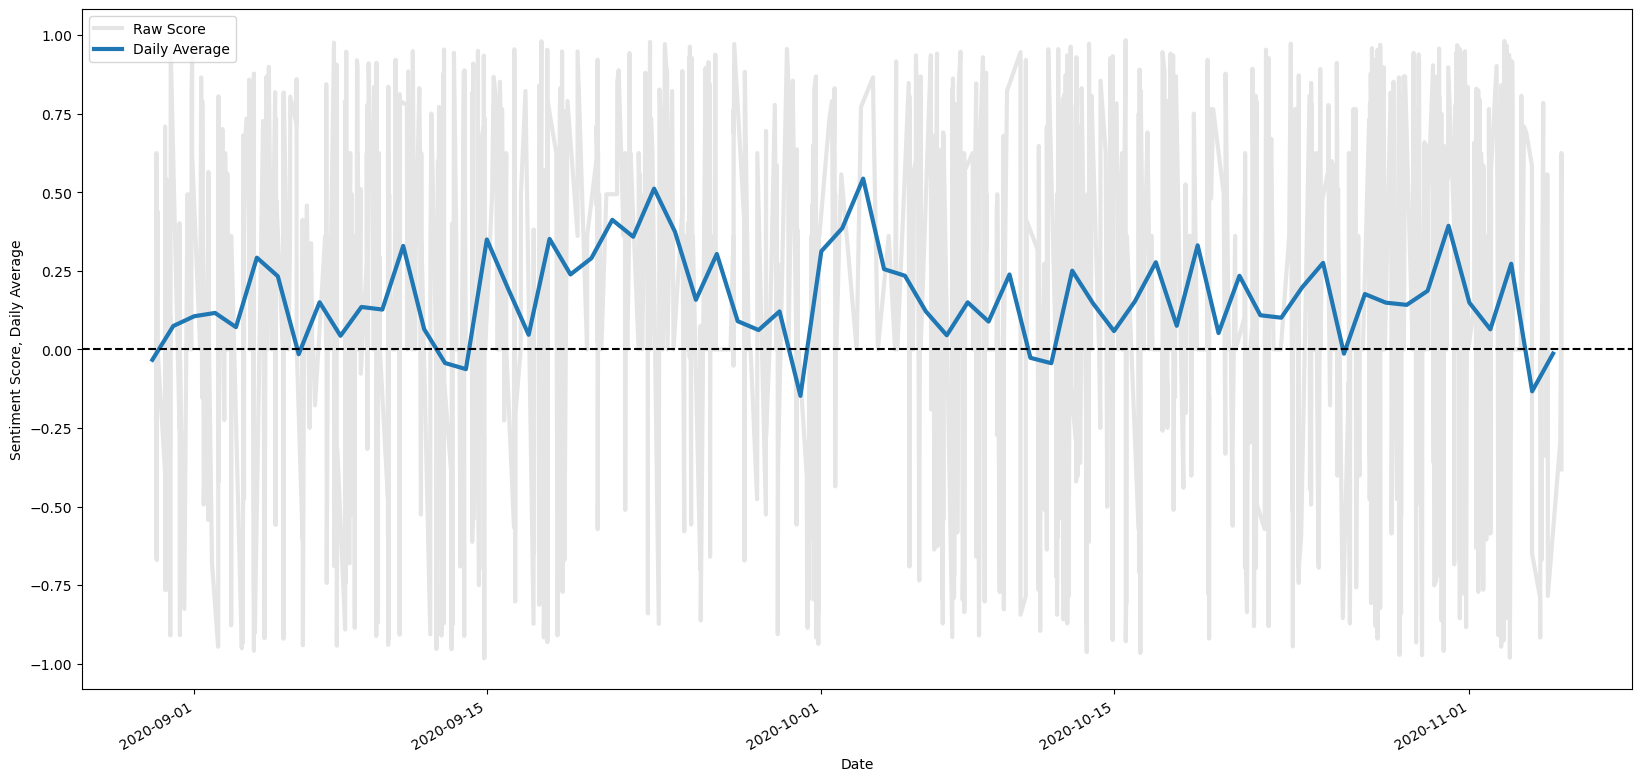

In [28]:
f,a = plt.subplots(figsize=(20,10))
# Plot sentiment score
sent_ts['sentiment'].plot(alpha=.1, # Set it to be transparent
                          ax=a, # Plot on that axis
                          color="black", # Color sentiment black
                          label="Raw Score", # Label "Raw Score"
                          lw=3) # Make the line width = 3

# The daily average
df.groupby("date")['sentiment'].mean().plot(ax=a,label="Daily Average",lw=3)
# Give it the origin line (0)
plt.axhline(0,color="black",ls="--")
# Label
plt.ylabel("Sentiment Score, Daily Average")
plt.xlabel("Date")
# Legend
plt.legend()

#### What do the happiest and saddest tweets look like?

In [29]:
# Setting the index as the time stamp 
# Sort by sentiment, lowest on top, take first 5
df.set_index("time_stamp").sort_values("sentiment",ascending=True)[['full_text','sentiment']].head() 

,full_text,sentiment
time_stamp,,
2020-09-14 21:04:33+00:00,"According to press reports, Iran may be planning an assassination, or other attack, against the United States in retaliation for the killing of terrorist leader Soleimani, which was carried out for his planning a future attack, murdering U.S. Troops, and the death &amp; suffering...",-0.9829
2020-11-02 22:25:17+00:00,"Our prayers are with the people of Vienna after yet another vile act of terrorism in Europe. These evil attacks against innocent people must stop. The U.S. stands with Austria, France, and all of Europe in the fight against terrorists, including radical Islamic terrorists.",-0.9810
2020-10-29 17:34:47+00:00,"Failed RINO former Governor Rick Snyder of Michigan was a disaster with respect to the Flint Water CATASTROPHE, and a very bad Governor overall. He hurt so many people with his gross incompetence. He reminds me of Sleepy Joe!",-0.9729
2020-10-28 15:42:48+00:00,"Who is Miles Taylor? Said he was “anonymous”, but I don’t know him - never even heard of him. Just another @nytimes SCAM - he worked in conjunction with them. Also worked for Big Tech’s @Google. Now works for Fake News @CNN. They should fire, shame, and punish everybody....",-0.9721
2020-10-16 06:15:38+00:00,"Steve Scully of @cspan had a very bad week. When his name was announced, I said he would not be appropriate because of conflicts. I was right! Then he said he was hacked, he wasn’t. I was right again! But his biggest mistake was “confiding” in a lowlife loser like the Mooch. Sad!",-0.9659


The top two saddest tweets are about terrorism and assasination, the rest have an agressive tone speaking about various people.

In [30]:
# Do the same, but highest on top
df.set_index("time_stamp").sort_values("sentiment",ascending=False)[['full_text','sentiment']].head()

,full_text,sentiment
time_stamp,,
2020-10-15 13:20:21+00:00,"It was great to be back in North Carolina with thousands of loyal, hardworking American Patriots! This election is a simple choice: If Biden Wins, China Wins. When WE Win, YOU WIN, North Carolina WINS, and America WINS! https://t.co/jWYVYZdT3E",0.9843
2020-11-02 16:12:45+00:00,"As Christians throughout this great Country celebrate All Souls Day, let’s remember those who went before us and built this great nation. May their legacy inspire us as we keep our nation what it has always been: blessed and great!",0.9816
2020-09-17 14:38:16+00:00,"I would like to extend best wishes and a very happy 70th birthday to the Prime Minister of India, @narendramodi. Many happy returns to a GREAT LEADER and loyal friend! https://t.co/CWlVkHk16X",0.9806
2020-09-22 19:20:26+00:00,"I was honored to be back in the Commonwealth of Pennsylvania with thousands of loyal, hardworking American Patriots. This election is a choice between Pennsylvania &amp; China. If Biden wins, China wins. When we win, Pennsylvania Wins, and AMERICA WINS! #MAGA https://t.co/GTSNoUDpHf",0.9788
2020-09-07 16:30:32+00:00,"Congratulations to Dustin Johnson @DJohnsonPGA on not only a great winning streak and golf season, but on capping it off with a fantastic @PGA Tour Championship and becoming the 2020 FEDEXCUP Champion. Dustin is a true WINNER in so many ways!",0.9762


Notice the happy tweets have things like "happy," "blessed," "winner," and so forth.

### "Happiest and Saddest Words"

#### Words that correlate with sentiment.
correlate word counts with sentiment score.

In [31]:
# Add the "sentiment" column, but using join instead of concat
# (you can do this when the indices are the same)
word_df = word_df.join(df[['sentiment']])
# Look at the correlation of "sentiment" with the other words
sent_words_corr = word_df.corr()['sentiment']

###### Bad words

In [32]:
# Put lowest correlation on top, first 20
sent_words_corr.sort_values().head(20)

fake         -0.227624
bad          -0.171513
disaster     -0.158893
biden’s      -0.147969
joe          -0.143081
news         -0.138661
death        -0.136131
wrong        -0.135556
scam         -0.134479
democrat     -0.130202
biden        -0.129504
swine        -0.127603
pathetic     -0.125120
failed       -0.123546
ban          -0.122004
loser        -0.119895
ballots      -0.118333
terrorists   -0.114945
rigged       -0.114247
sleepy       -0.113770
Name: sentiment, dtype: float64

Besides the typical negative words, "Biden," "fake," and "news," "swine," and "ballots" are notable exceptions. While these are not necessarily bad words by themselves, what this shows is the Trump combines these words with other negative words.

###### Good Words

In [33]:
# Put highest on top, first 21
sent_words_corr.sort_values(ascending=False).head(21)

sentiment          1.000000
great              0.387357
thank              0.234837
endorsement        0.219047
complete           0.199770
america            0.180519
strong             0.177361
win                0.176321
amendment          0.174089
second             0.161492
congressman        0.155843
honor              0.146144
total              0.145765
wins               0.128741
best               0.126742
brave              0.126025
make               0.124416
incredible         0.117162
vets               0.115542
protect            0.110068
congratulations    0.109247
Name: sentiment, dtype: float64

Most of these are good words already, but notice "congressman," "vets," "amendment" (referring to second amendment), and "America" as words that Trump includes in his most positive tweets.

## Trump and the Stock Market

Did Trump's tweeting affect stock prices?

### First discuss in groups!
- What is the mechanism by which Trump tweeting would affect markets?
- What direction do you expect the effect to be?

We can merge some data in to examine the series together...

In [34]:
# Read in S&P500, daily closing
sp500 = pd.read_csv(dir_+"SandP500.csv")

### A note on data merging:
In order for the merge to work, each data source needs to be at the same level.

In this case:
- Tweets are at the second level
- Prices are at the daily level

So make sure some column exists in both datasets to merge on:

In [36]:
# Rename this column the same as the other one
sp500['date'] = pd.to_datetime(sp500['DATE'])

# Merge on date
df = df.merge(sp500,how='left',on='date',indicator='i_')

# Convert that to numeric
df['SP500'] =pd.to_numeric(df['SP500'],errors='coerce')

# Average the sentiment and the S&P500
price_and_sent = df.groupby("date")[['sentiment','SP500']].mean()

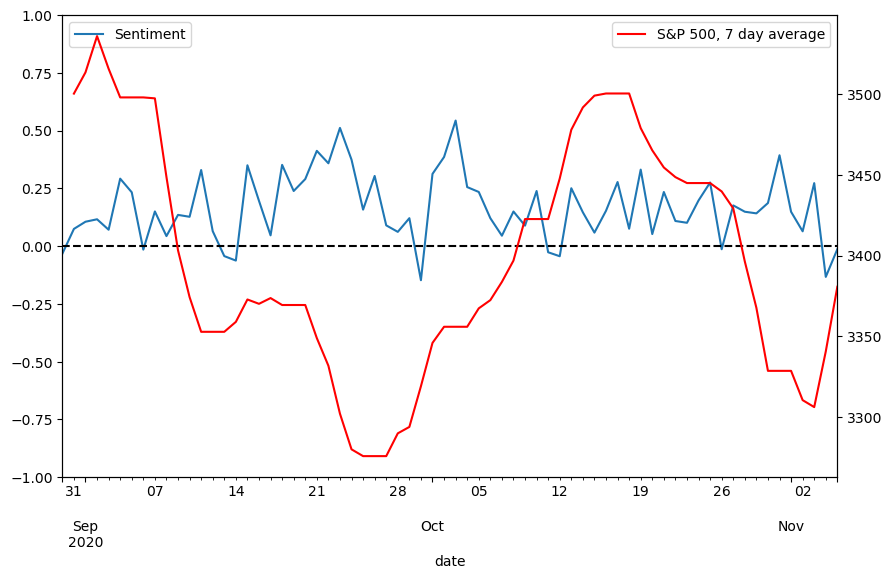

In [37]:
f,a = plt.subplots(figsize=(10,6))
# Plot the sentiment on axis a
price_and_sent['sentiment'].plot(ax=a,label="Sentiment")
# Line at 0
plt.axhline(0,color="black",ls="--")
# Put the legend in the upper left
plt.legend(loc='upper left')
# Set the ylimit between -1 and 1
a.set_ylim(-1,1)
# Twin x
a2 = a.twinx()
# Plot S&P weekly average on a2
price_and_sent['SP500'].rolling(7,min_periods=1).mean().plot(ax=a2,color='red',label="S&P 500, 7 day average")
# Make a legend for that other plot
plt.legend()

### Group Discussion:
how you would answer the question: "Did President Trump's tweet sentiment influence the stock market?" Specifically describe:
- The data you would need in addition to these data sources.
- The way you would read in the data and manipulate it.
- The sort of analysis or statistics you would calculate to answer the question.

In [38]:
price_and_sent.corr()

,sentiment,SP500
sentiment,1.000000,-0.415257
SP500,-0.415257,1.000000


There is a somehwhat strong correlation between Trump's sentiment and S&P 500, but it is __negative__: the more positive Trump's Tweets are the lower stock prices are. A couple of possibilities:
- Spurious correlation ([for example](https://www.tylervigen.com/spurious-correlations)).
- Omitted variable bias: there is something that drives Trump's sentiment but also drives stock prices, which makes the relationship look stronger than it actually is. Certain events may be to blame more than Trump or the stock market; for example, certain events could be affecting both in opposite ways. This means it is __not a causal relationship__.
- Trump interprets things positively that the market inteprets as bearish. For example, many positive Trump tweets were congratulating the victories of certain politicians or policies that market may not welcome. This would __not be a causal relationship__. 
- Trump's comments during this period promoted distrust in institutions (such as mail-in voting) and were thought of as destabilizing, which the market may have interpreted as a bad signal for the economy. This would also be a __causal relationship__.

Note that the sizable jump in the stock market following November 3 indicate that Trump leaving office did appear to affect markets, since that was the most major event happening at the time.